In [1]:
# Imports & config

import os
import sys
import subprocess

# Make sure required libs exist (run pip only if missing)
def ensure_package(pkg):
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for p in ["torch", "torchvision", "albumentations", "transformers", "opencv-python-headless"]:
    ensure_package(p)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import numpy as np
import cv2
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

from transformers import SegformerForSemanticSegmentation

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# your processed data folder
DATA_ROOT = "/workspace/ML Main Large/Processed data"

IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 15   # you can change to 20 if you want

Installing opencv-python-headless ...


DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/igraph-0.11.8-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.0.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/texttable-1.7.0-py3.12.egg is deprecated. pip 25.1 will

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


DEVICE: cuda


In [2]:
# Dataset & transforms

class RoadTrainDataset(Dataset):
    """
    Uses images + masks from Processed data/train
    """
    def __init__(self, root, split="train", transform=None):
        self.img_dir = os.path.join(root, split, "images")
        self.mask_dir = os.path.join(root, split, "masks")

        self.img_paths = sorted(glob(os.path.join(self.img_dir, "*")))
        self.mask_paths = sorted(glob(os.path.join(self.mask_dir, "*")))
        assert len(self.img_paths) == len(self.mask_paths) and len(self.img_paths) > 0, \
            "Train images & masks count mismatch or empty."

        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        mask_path = self.mask_paths[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype("float32")  # 0/1

        # resize defensively
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"]

        # mask shape: [H,W] -> [1,H,W]
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return img, mask


class RoadImageDataset(Dataset):
    """
    For valid/test: only images, no masks.
    """
    def __init__(self, root_split):
        # root_split is something like: "/workspace/.../Processed data/valid/images"
        self.img_paths = sorted(glob(os.path.join(root_split, "*")))
        self.transform = A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        aug = self.transform(image=img)
        img_t = aug["image"]
        return img_t, img_path


# Albumentations transforms for training & inference
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(),
    ToTensorV2()
])

plain_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

In [3]:
# SegFormer-B0 model

class SegFormerB0(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.backbone = SegformerForSemanticSegmentation.from_pretrained(
            "nvidia/segformer-b0-finetuned-ade-512-512",
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )

    def forward(self, x):
        # x: [B,3,H,W], normalized
        out = self.backbone(pixel_values=x)
        logits = out.logits  # [B,1,h',w']
        # upsample to input size
        logits = F.interpolate(
            logits,
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False
        )
        return logits


# sanity: create model & show params
model_tmp = SegFormerB0().to(DEVICE)
n_params = sum(p.numel() for p in model_tmp.parameters() if p.requires_grad) / 1e6
print(f"SegFormer-B0 trainable params: {n_params:.3f}M")
del model_tmp
torch.cuda.empty_cache()

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([1]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([1, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SegFormer-B0 trainable params: 3.714M


In [4]:
# Loss, IoU, dataloaders, training

# Dice + BCE
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)
    inter = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2 * inter + eps) / (union + eps)
    return 1 - dice.mean()

def total_loss(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

def iou_score(pred, mask, eps=1e-6):
    """
    pred: logits [B,1,H,W]
    mask: [B,1,H,W]
    """
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * mask).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + mask.sum(dim=(2,3)) - inter
    iou = (inter + eps) / (union + eps)
    return iou.mean()


#  Dataloaders (train only, valid/test only for inference later) 

train_ds = RoadTrainDataset(DATA_ROOT, "train", train_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print("Train samples:", len(train_ds))


#  Training loop on TRAIN ONLY 

def train_segformer_b0():
    model = SegFormerB0().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler()

    best_iou = 0.0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        running_iou = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
        for imgs, masks in pbar:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                logits = model(imgs)
                loss = total_loss(logits, masks)
                iou = iou_score(logits, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            running_iou += iou.item()

            pbar.set_postfix({
                "loss": f"{running_loss / len(train_loader):.3f}",
                "iou": f"{running_iou / len(train_loader):.3f}"
            })

        epoch_loss = running_loss / len(train_loader)
        epoch_iou = running_iou / len(train_loader)
        print(f"Train Loss: {epoch_loss:.4f} | Train IoU: {epoch_iou:.4f}")

        if epoch_iou > best_iou:
            best_iou = epoch_iou
            torch.save(model.state_dict(), "segformer_b0_best.pth")
            print("✅ Saved BEST model with IoU:", best_iou)

    print("Training complete. Best IoU:", best_iou)
    return model


# actually train
model = train_segformer_b0()

Train samples: 14688


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([1]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([1, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

poch 1/15: 100%|██████████| 3672/3672 [01:21<00:00, 44.93it/s, loss=0.327, iou=0.359]

Train Loss: 0.3266 | Train IoU: 0.3592
✅ Saved BEST model with IoU: 0.359207945586307



poch 2/15: 100%|██████████| 3672/3672 [01:20<00:00, 45.80it/s, loss=0.289, iou=0.399]

Train Loss: 0.2886 | Train IoU: 0.3985
✅ Saved BEST model with IoU: 0.39851918926742536


...

Train Loss: 0.2633 | Train IoU: 0.4382



poch 14/15: 100%|██████████| 3672/3672 [01:21<00:00, 44.88it/s, loss=0.263, iou=0.440]

Train Loss: 0.2625 | Train IoU: 0.4401
✅ Saved BEST model with IoU: 0.4400857675887547



poch 15/15: 100%|██████████| 3672/3672 [01:22<00:00, 44.71it/s, loss=0.262, iou=0.439]

Train Loss: 0.2620 | Train IoU: 0.4388
Training complete. Best IoU: 0.4400857675887547


In [5]:
# Prediction helper (valid/test) + save predicted masks

# reload best model
model = SegFormerB0().to(DEVICE)
model.load_state_dict(torch.load("segformer_b0_best.pth", map_location=DEVICE))
model.eval()

def predict_mask_single(img_path):
    """
    Returns:
      img_rgb (H,W,3),
      pred_mask_uint8 (H,W) in 0..255
    """
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print("Cannot read:", img_path)
        return None, None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # resize + normalize
    aug = plain_transform(image=cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)))
    img_t = aug["image"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(img_t)          # [1,1,H,W]
        prob = torch.sigmoid(logits)[0,0].cpu().numpy()  # [H,W]

    # back to original resolution
    prob_resized = cv2.resize(prob, (w, h), interpolation=cv2.INTER_LINEAR)
    mask_uint8 = (prob_resized * 255).astype("uint8")

    return img_rgb, mask_uint8


# Save predictions for TEST 

TEST_IMG_DIR  = os.path.join(DATA_ROOT, "test", "images")

SAVE_TEST_DIR  = "segformer_test_predictions"
os.makedirs(SAVE_TEST_DIR, exist_ok=True)

def save_predictions_for_split(img_dir, save_dir, max_images=None):
    files = sorted(os.listdir(img_dir))
    if max_images is not None:
        files = files[:max_images]

    print(f"Found {len(files)} images in {img_dir}")
    for f in tqdm(files, desc=f"Predicting in {os.path.basename(img_dir)}"):
        if f.startswith(".") or f.endswith(".ipynb_checkpoints"):
            continue

        img_path = os.path.join(img_dir, f)
        img, mask = predict_mask_single(img_path)
        if img is None:
            continue

        base, ext = os.path.splitext(f)
        save_path = os.path.join(save_dir, f"{base}_segformer_mask.png")
        cv2.imwrite(save_path, mask)

    print(f"Predictions saved in {save_dir}")

save_predictions_for_split(TEST_IMG_DIR, SAVE_TEST_DIR)

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([1]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([1, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Found 13082 images in /workspace/ML Main Large/Processed data/test/images


Predicting in images: 100%|██████████| 13082/13082 [01:28<00:00, 147.02it/s]

Predictions saved in segformer_test_predictions


Showing: 15607_sat.jpg


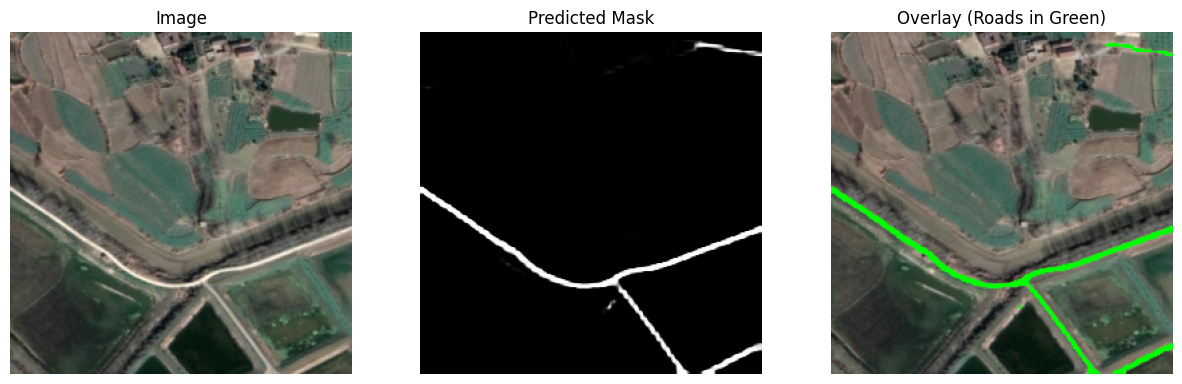

Showing: 15608_sat.jpg


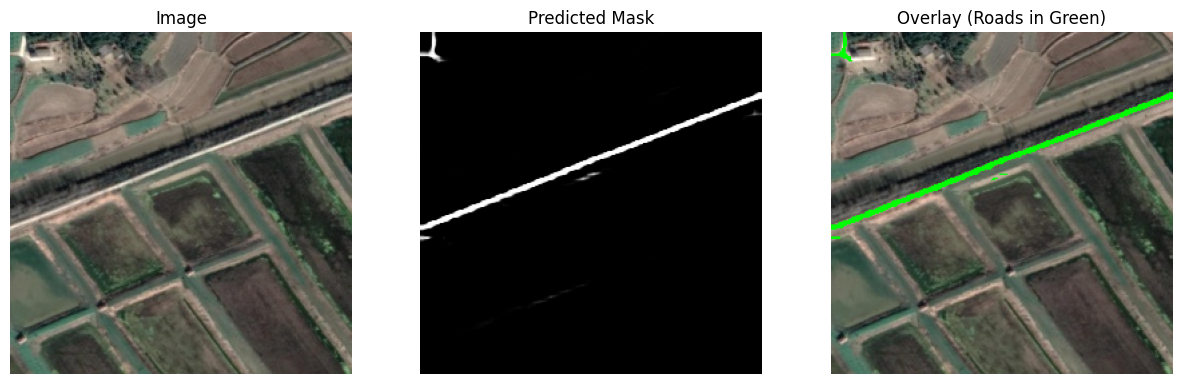

Showing: 15609_sat.jpg


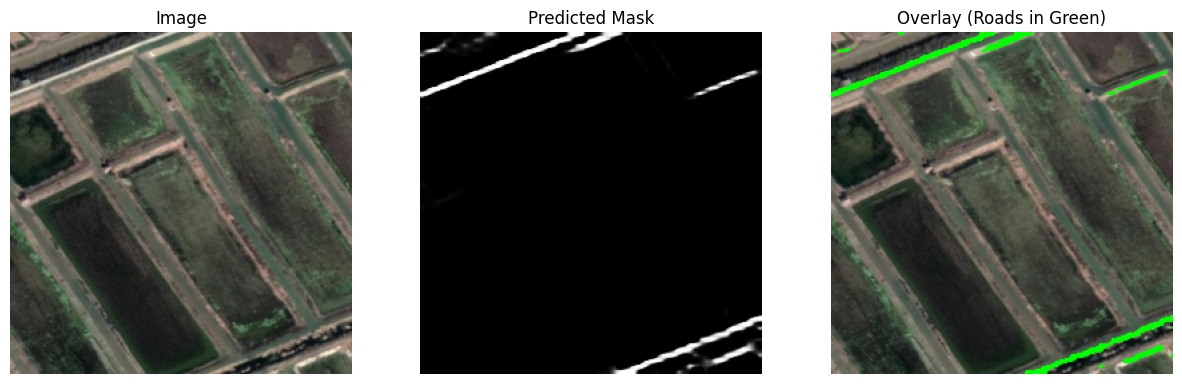

Showing: 15612_sat.jpg


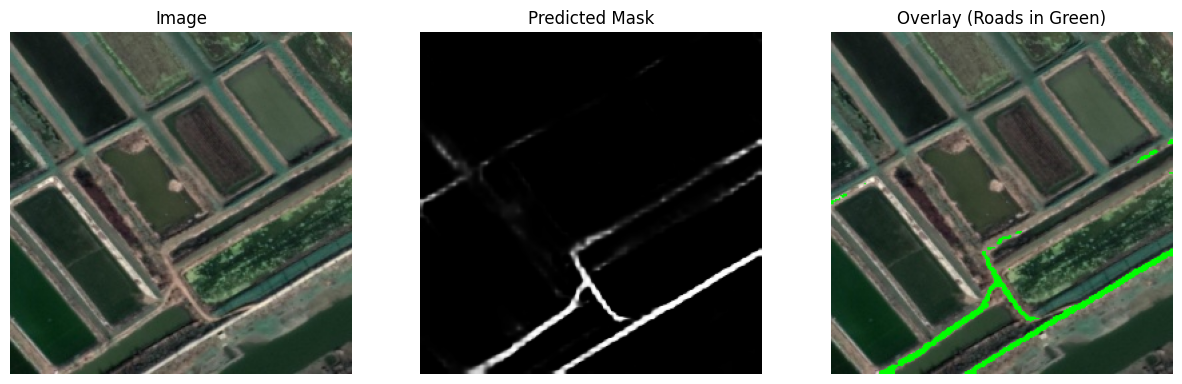

Showing: 15613_sat.jpg


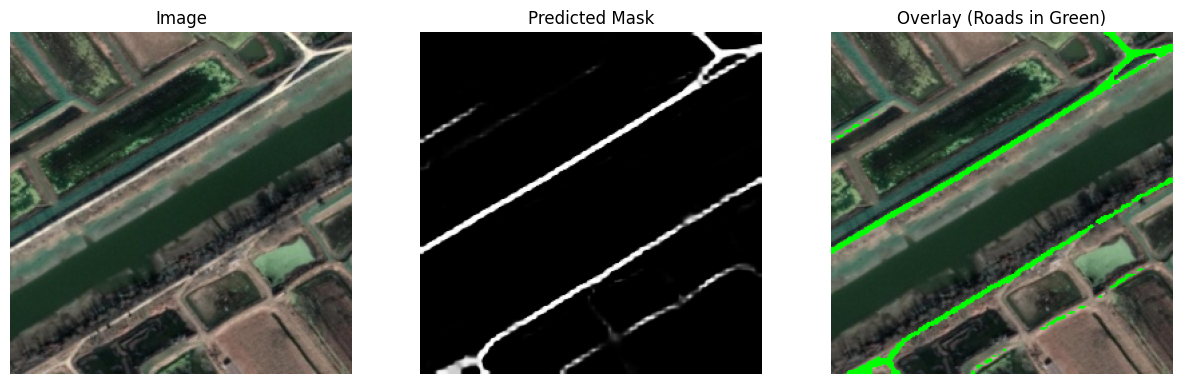

In [8]:
# Visualization for some TEST images

def show_prediction(img_path):
    img, mask = predict_mask_single(img_path)
    if img is None:
        return

    overlay = img.copy()
    # color the predicted road pixels green
    overlay[mask > 127] = [0, 255, 0]

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Predicted Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay (Roads in Green)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()


# show a few from VALID
test_files = sorted(os.listdir(TEST_IMG_DIR))
test_files = [f for f in test_files if not f.startswith(".")]

for f in test_files[:5]:
    print("Showing:", f)
    show_prediction(os.path.join(TEST_IMG_DIR, f))

In [9]:
def evaluate_saved_model(model_path, dataset, batch_size=4):
    """
    Evaluate a saved SegFormer-B0 model on any dataset 
    that returns (image, mask) pairs.
    """

    print(f"\nLoading saved model from: {model_path}")
    model = SegFormerB0().to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    total_loss_sum = 0.0
    total_iou_sum = 0.0
    total_batches = len(loader)

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")

        for imgs, masks in pbar:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(imgs)

            # Compute losses
            bce_l = bce_loss(logits, masks).item()
            dice_l = dice_loss(logits, masks).item()
            tot_l  = total_loss(logits, masks).item()

            # Compute IoU
            batch_iou = iou_score(logits, masks).item()

            total_loss_sum += tot_l
            total_iou_sum  += batch_iou

            pbar.set_postfix({
                "loss": f"{tot_l:.4f}",
                "iou": f"{batch_iou:.4f}"
            })

    avg_loss = total_loss_sum / total_batches
    avg_iou  = total_iou_sum  / total_batches

    print("\nFINAL EVALUATION")
    print(f"Avg Total Loss : {avg_loss:.6f}")
    print(f"Avg IoU        : {avg_iou:.6f}")

    return avg_loss, avg_iou

In [10]:
train_ds = RoadTrainDataset(DATA_ROOT, "train", transform=plain_transform)
evaluate_saved_model("segformer_b0_best.pth", train_ds)


Loading saved model from: segformer_b0_best.pth


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([1]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([1, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

valuating: 100%|██████████| 3672/3672 [03:51<00:00, 15.85it/s, loss=0.3216, iou=0.3148]


FINAL EVALUATION
Avg Total Loss : 0.250500
Avg IoU        : 0.458312


(0.25049993863495673, 0.45831192329151343)